In [1]:
import pandas as pd

print("Pandas Installed Successfully")

Pandas Installed Successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("Setup Successful")


Pandas: 2.3.3
Setup Successful


In [2]:
import pyodbc

print("pyodbc installed successfully")

pyodbc installed successfully


In [3]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    r"DRIVER={SQL Server};"
    r"SERVER=localhost\SQLEXPRESS;"
    r"DATABASE=RetailSalesDB;"
    r"Trusted_Connection=yes;"
)

query = "SELECT TOP 5 * FROM Retail_Data_Transactions"

df = pd.read_sql(query, conn)

df

C:\Users\thepr\AppData\Local\Temp\ipykernel_9824\506541010.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,customer_id,trans_date,tran_amount
0,CS5295,2013-02-11,35.0
1,CS4768,2015-03-15,39.0
2,CS2122,2013-02-26,52.0
3,CS1217,2011-11-16,99.0
4,CS1850,2013-11-20,78.0


In [4]:
query = """
SELECT *
FROM Retail_Data_Transactions
"""

transactions_df = pd.read_sql(query, conn)

transactions_df.shape

C:\Users\thepr\AppData\Local\Temp\ipykernel_9824\2389385679.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions_df = pd.read_sql(query, conn)


(125000, 3)

In [5]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   customer_id  125000 non-null  object 
 1   trans_date   125000 non-null  object 
 2   tran_amount  125000 non-null  float64
dtypes: float64(1), object(2)
memory usage: 2.9+ MB


In [6]:
transactions_df.describe()

,tran_amount
count,125000.000000
mean,64.991912
std,22.860006
min,10.000000
25%,47.000000
50%,65.000000
75%,83.000000
max,105.000000


In [7]:
transactions_df['trans_date'] = pd.to_datetime(
    transactions_df['trans_date']
)

In [8]:
transactions_df['MonthYear'] = (
    transactions_df['trans_date']
    .dt.to_period('M')
)

In [9]:
monthly_sales = (
    transactions_df
    .groupby('MonthYear')['tran_amount']
    .sum()
)

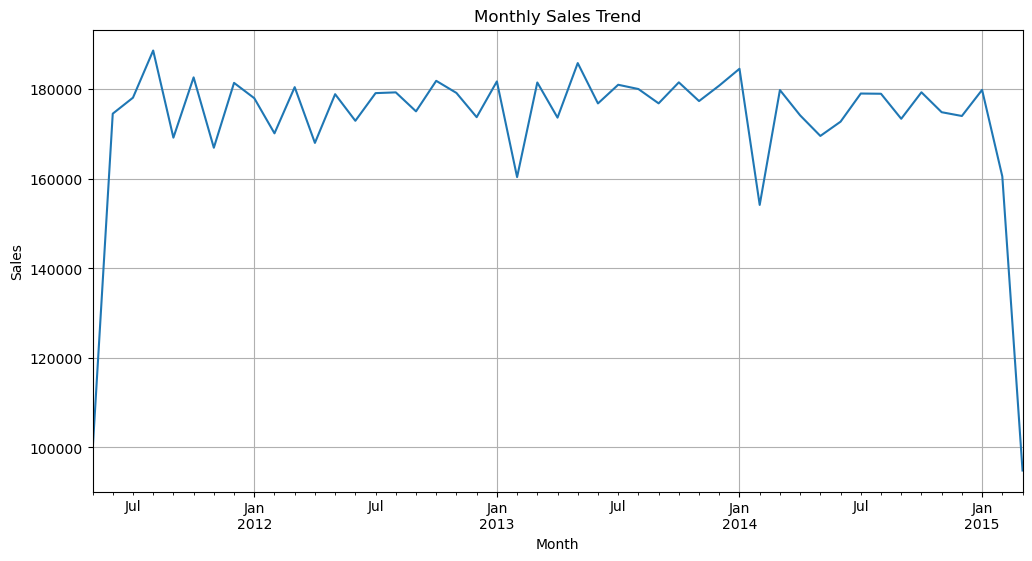

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.grid(True)

plt.show()

In [11]:
top_customers = (
    transactions_df
    .groupby('customer_id')['tran_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

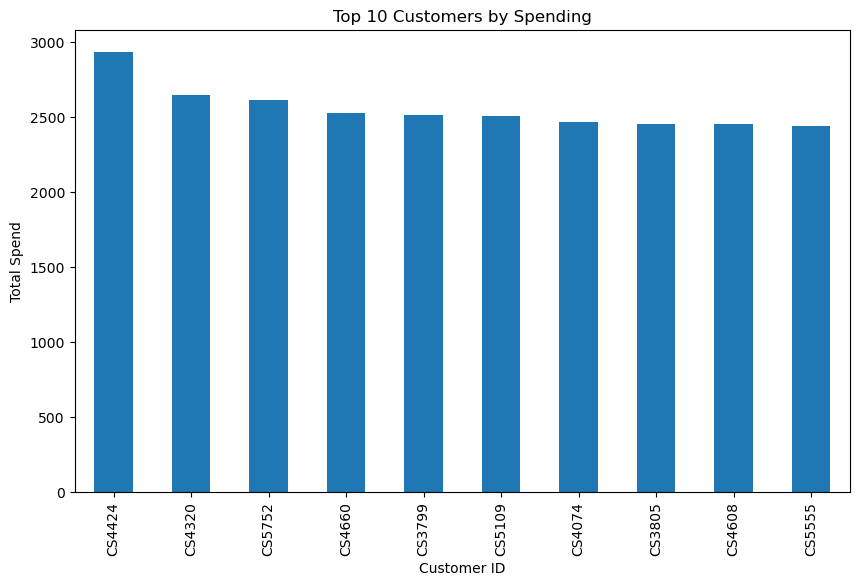

In [12]:
plt.figure(figsize=(10,6))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spend')

plt.show()

In [13]:
transactions_df.shape

(125000, 4)

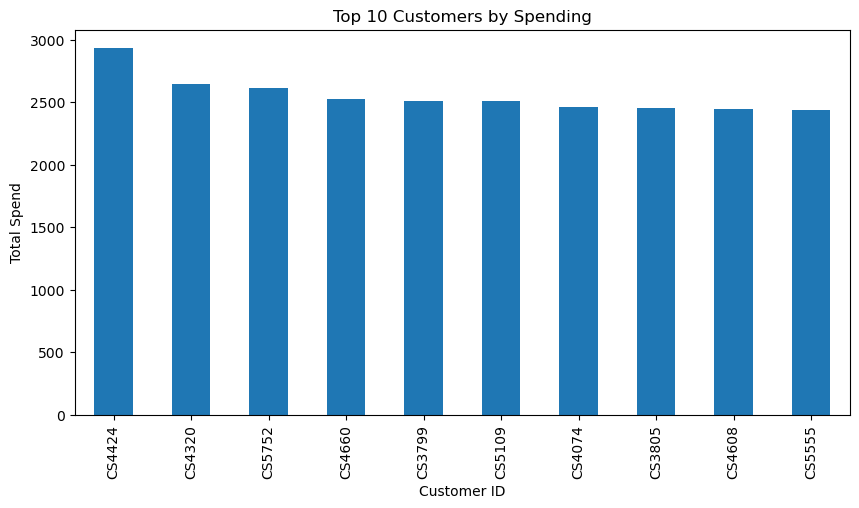

In [14]:
top_customers = (
    transactions_df
    .groupby('customer_id')['tran_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend")

plt.show()

In [15]:
response_df = pd.read_sql(
    "SELECT * FROM Retail_Data_Response",
    conn
)

response_df.head()

C:\Users\thepr\AppData\Local\Temp\ipykernel_9824\1902307612.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  response_df = pd.read_sql(


,customer_id,response
0,CS8813,0
1,CS8814,0
2,CS8815,0
3,CS8816,0
4,CS8817,0


In [16]:
response_df.shape

(6884, 2)

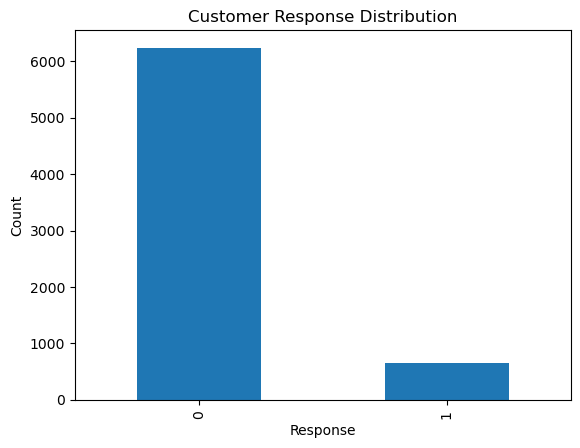

In [17]:
response_counts = (
    response_df['response']
    .value_counts()
)

response_counts.plot(
    kind='bar'
)

plt.title("Customer Response Distribution")
plt.xlabel("Response")
plt.ylabel("Count")

plt.show()

In [18]:
plt.savefig("monthly_sales_trend.png")

<Figure size 640x480 with 0 Axes>

In [19]:
plt.savefig("top_customers.png")

<Figure size 640x480 with 0 Axes>

In [20]:
import os

print(os.getcwd())

C:\Users\thepr


In [21]:
import os

os.path.exists(r"C:\Users\thepr\OneDrive\Desktop\projects\istudio\charts")

False

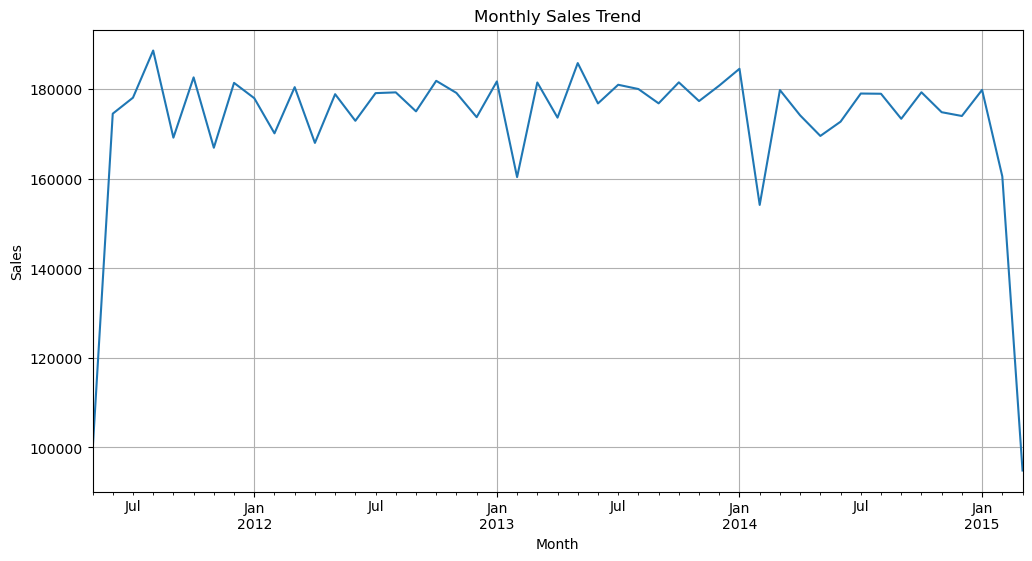

In [22]:
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.savefig(
    r"A:\OneDrive\Desktop\projects\istudio\charts\monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

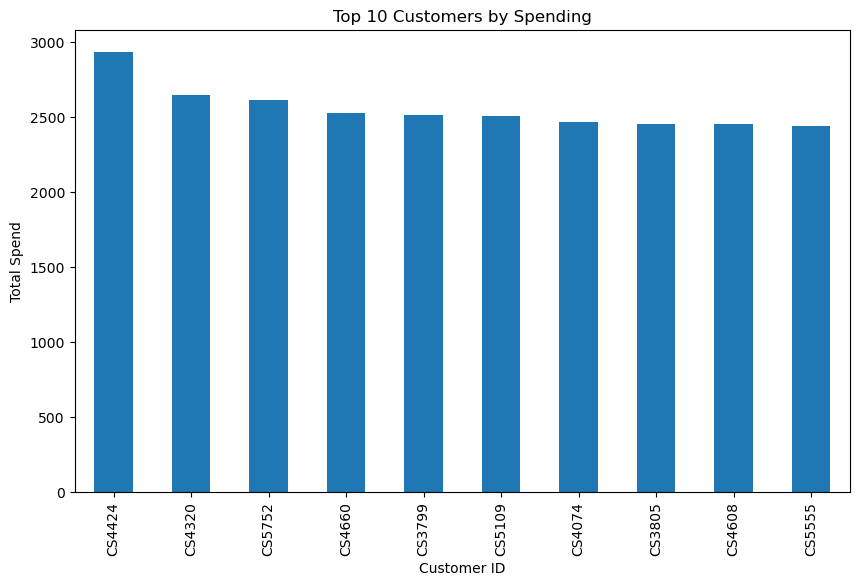

In [23]:
plt.figure(figsize=(10,6))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend")

plt.savefig(
    r"A:\OneDrive\Desktop\projects\istudio\charts\top_10_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
import os

print(os.listdir(r"A:\OneDrive\Desktop\projects\istudio\charts"))

['monthly_sales_trend.png', 'top_10_customers.png']


C:\Users\thepr\AppData\Local\Temp\ipykernel_9824\867150043.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  response_df = pd.read_sql(


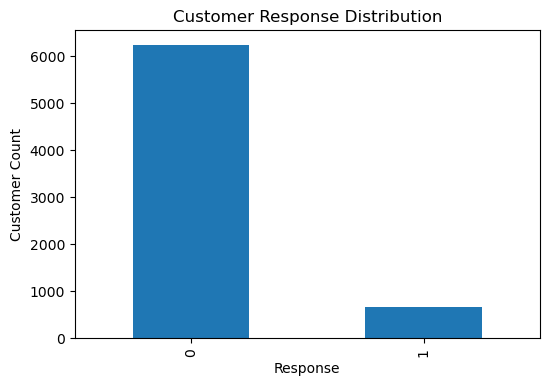

In [25]:
response_df = pd.read_sql(
    "SELECT * FROM Retail_Data_Response",
    conn
)

response_counts = response_df['response'].value_counts()

plt.figure(figsize=(6,4))

response_counts.plot(kind='bar')

plt.title("Customer Response Distribution")
plt.xlabel("Response")
plt.ylabel("Customer Count")

plt.savefig(
    r"A:\OneDrive\Desktop\projects\istudio\charts\customer_response_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()